<h1>Ансамбли моделей машинного обучения. Часть 2.</h1>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
%matplotlib inline 
sns.set(style="ticks")
data = pd.read_csv('Spotify_Music.csv', sep=",")

data.head(5)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [2]:
print(data.isnull().sum())

data_cleaned = data.dropna()

print(f"\nРазмер данных до очистки: {data.shape}")
print(f"Размер данных после очистки: {data_cleaned.shape}")

data_cleaned = data_cleaned.drop(["Unnamed: 0", "track_id", "track_name", "album_name"], axis=1)

print(f"\nУникальные значения в столбцах до очистки: {data.nunique()}")
print(f"\nУникальные значения в столбцах после очистки: {data_cleaned.nunique()}")

data = data_cleaned

data.head(5)

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Размер данных до очистки: (114000, 21)
Размер данных после очистки: (113999, 21)

Уникальные значения в столбцах до очистки: Unnamed: 0          114000
track_id             89741
artists              31437
album_name           46589
track_name           73608
popularity             101
duration_ms          50697
explicit                 2
danceability          1174
energy                2083
key                     12
loudness             19480
mode                     2
speechiness           1489
acousticness         

,artists,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,Gen Hoshino,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,Ben Woodward,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,Ingrid Michaelson;ZAYN,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,Kina Grannis,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,Chord Overstreet,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [3]:
data['duration_sec'] = data['duration_ms'] / 1000

q01 = data['duration_sec'].quantile(0.01)
q99 = data['duration_sec'].quantile(0.99)
data['duration_clipped'] = data['duration_sec'].clip(q01, q99)

data['duration_log'] = np.log1p(data['duration_clipped'])

data = data.drop('duration_ms', axis=1)

In [4]:
data['tempo'] = data['tempo'].fillna(data['tempo'].median())

data['tempo_clipped'] = data['tempo'].clip(60, 220)

data = data.drop('tempo', axis=1)

In [5]:
artist_counts = data['artists'].value_counts()
        
data['artist_freq'] = data['artists'].map(artist_counts)
data['artist_freq_log'] = np.log1p(data['artist_freq'])

data['artist_is_rare'] = (data['artist_freq'] < 5).astype(int)
data['artist_is_single'] = (data['artist_freq'] == 1).astype(int)

data = data.drop('artists', axis=1)

In [6]:
data['explicit'] = data['explicit'].astype(int)
le_genre = LabelEncoder()
data['track_genre_label'] = le_genre.fit_transform(data['track_genre'])
data = data.drop('track_genre', axis=1)

In [7]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(data, test_size=0.3, random_state=42)

print(f"Размер обучающей выборки: {train_data.shape}")
print(f"Размер тестовой выборки: {test_data.shape}")


Размер обучающей выборки: (79799, 22)
Размер тестовой выборки: (34200, 22)


In [8]:
TARGET = 'popularity'

X_train = train_data.drop(columns=[TARGET])
y_train = train_data[TARGET]

X_test = test_data.drop(columns=[TARGET])
y_test = test_data[TARGET]

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train — min: {y_train.min()}, max: {y_train.max()}, mean: {y_train.mean():.2f}")

X_train: (79799, 21), X_test: (34200, 21)
y_train — min: 0, max: 100, mean: 33.31


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [10]:
from sklearn.ensemble import StackingRegressor, RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import time

base_estimators = [
    ('rf',  RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ('gb',  HistGradientBoostingRegressor(max_iter=100, random_state=42)),
    ('knn', KNeighborsRegressor(n_neighbors=5, n_jobs=-1)),
]

meta_model = Ridge(alpha=1.0)

stacking_reg = StackingRegressor(
    estimators=base_estimators,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1,
    passthrough=False
)

print("Обучение StackingRegressor...")
t0 = time.time()
stacking_reg.fit(X_train_scaled, y_train)
print(f"Время обучения: {time.time()-t0:.1f} с")

y_pred_stacking = stacking_reg.predict(X_test_scaled)
rmse_stacking = mean_squared_error(y_test, y_pred_stacking) ** 0.5
r2_stacking   = r2_score(y_test, y_pred_stacking)
print(f"\nStackingRegressor — RMSE: {rmse_stacking:.4f} | R²: {r2_stacking:.4f}")

Обучение StackingRegressor...
Время обучения: 230.5 с

StackingRegressor — RMSE: 14.9569 | R²: 0.5489


In [11]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
import time

mlp_improved = MLPRegressor(
    hidden_layer_sizes=(512, 256, 128, 64),  # глубже
    activation='relu',
    solver='adam',
    alpha=1e-3,              
    batch_size=512,          
    learning_rate='adaptive',
    learning_rate_init=1e-3,
    max_iter=200,        
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=42
)

print("Обучение улучшенного MLPRegressor...")
t0 = time.time()
mlp_improved.fit(X_train_scaled, y_train)
print(f"\nВремя обучения: {time.time()-t0:.1f} с")

y_pred_mlp = mlp_improved.predict(X_test_scaled)
rmse_mlp = mean_squared_error(y_test, y_pred_mlp) ** 0.5
r2_mlp   = r2_score(y_test, y_pred_mlp)
print(f"\nMLPRegressor (улучшенный) — RMSE: {rmse_mlp:.4f} | R²: {r2_mlp:.4f}")

Обучение улучшенного MLPRegressor...

Время обучения: 138.9 с

MLPRegressor (улучшенный) — RMSE: 19.0117 | R²: 0.2712


In [12]:
!pip install gmdh

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [13]:
from gmdh import Combi
import time

combi_model = Combi()

print("Обучение COMBI...")
t0 = time.time()
combi_model.fit(X_train_scaled, y_train.values)
print(f"Время обучения: {time.time()-t0:.1f} с")

y_pred_combi = combi_model.predict(X_test_scaled)
rmse_combi = mean_squared_error(y_test, y_pred_combi) ** 0.5
r2_combi   = r2_score(y_test, y_pred_combi)
print(f"\nCOMBI — RMSE: {rmse_combi:.4f} | R²: {r2_combi:.4f}")

Обучение COMBI...
Время обучения: 6903.4 с

COMBI — RMSE: 21.6871 | R²: 0.0516


In [44]:
from sklearn.preprocessing import MinMaxScaler
from gmdh import Mia, Criterion, CriterionType
import time

scaler_X = MinMaxScaler(feature_range=(0, 1))
X_train_gmdh_scaled = scaler_X.fit_transform(X_train)
X_test_gmdh_scaled  = scaler_X.transform(X_test)

scaler_y = MinMaxScaler(feature_range=(0, 1))
y_train_gmdh_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

mia_model = Mia()
print("Обучение MIA...")
t0 = time.time()
mia_model.fit(
    X_train_gmdh_scaled, y_train_gmdh_scaled,
    criterion=Criterion(CriterionType.REGULARITY),
    k_best=3,
    test_size=0.5
)
print(f"Время обучения: {time.time()-t0:.1f} с")

y_pred_mia_scaled = mia_model.predict(X_test_gmdh_scaled)
y_pred_mia = scaler_y.inverse_transform(y_pred_mia_scaled.reshape(-1, 1)).ravel()
y_pred_mia = np.clip(y_pred_mia, 0, 100)

rmse_mia = mean_squared_error(y_test, y_pred_mia) ** 0.5
r2_mia   = r2_score(y_test, y_pred_mia)
print(f"MIA — RMSE: {rmse_mia:.4f} | R²: {r2_mia:.4f}")

Обучение MIA...
Время обучения: 0.4 с
MIA — RMSE: 21.7222 | R²: 0.0486


           Модель      RMSE       R²
StackingRegressor 14.956866 0.548923
     MLPRegressor 19.011676 0.271197
     COMBI (МГУА) 21.687059 0.051646
       MIA (МГУА) 22.146715 0.011019


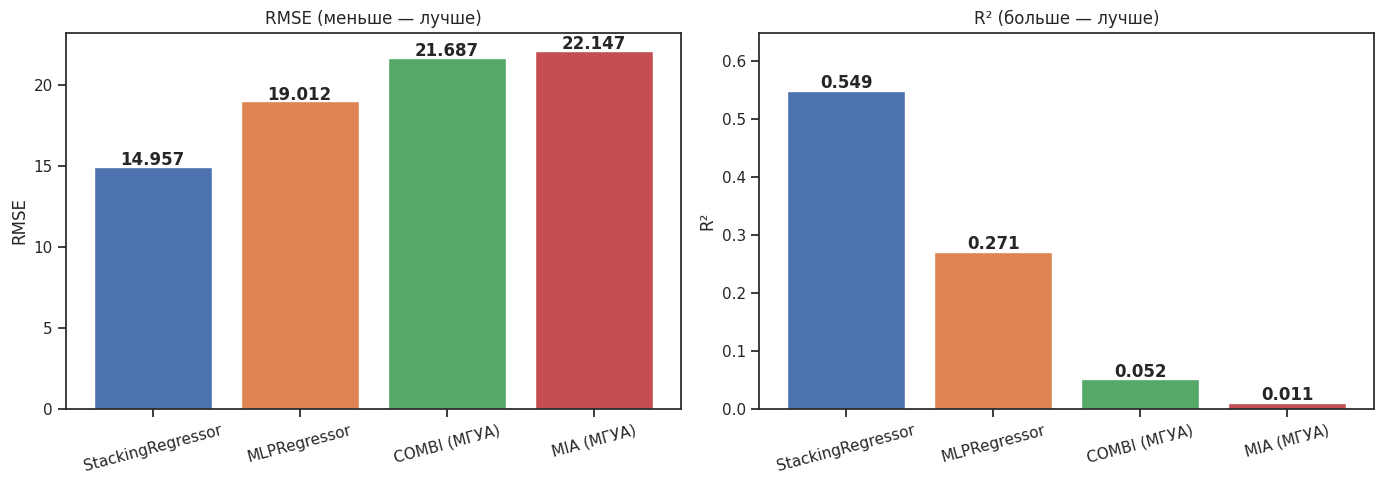

In [25]:
results_final = pd.DataFrame({
    'Модель': ['StackingRegressor', 'MLPRegressor', 'COMBI (МГУА)', 'MIA (МГУА)'],
    'RMSE':   [rmse_stacking, rmse_mlp, rmse_combi, rmse_mia],
    'R²':     [r2_stacking,   r2_mlp,   r2_combi,   r2_mia]
}).sort_values('R²', ascending=False).reset_index(drop=True)

print(results_final.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

axes[0].bar(results_final['Модель'], results_final['RMSE'], color=colors)
axes[0].set_title('RMSE (меньше — лучше)')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=15)
for i, row in results_final.iterrows():
    axes[0].text(i, row['RMSE'] + 0.1, f"{row['RMSE']:.3f}", ha='center', fontweight='bold')

axes[1].bar(results_final['Модель'], results_final['R²'], color=colors)
axes[1].set_title('R² (больше — лучше)')
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, max(results_final['R²']) + 0.1)
axes[1].tick_params(axis='x', rotation=15)
for i, row in results_final.iterrows():
    axes[1].text(i, row['R²'] + 0.005, f"{row['R²']:.3f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()